# Building a brain object

Brain objects are supereeg's fundamental data structure for a single subject's ECoG data.  To create one at minimum you'll need a matrix of neural recordings (time samples by electrodes), electrode locations, and a sample rate. Additionally, you can include information about separate recording sessions and store custom meta data. In this tutorial, we'll build a brain object from scratch and get familiar with some of the methods.

# Load in the required libraries

In [38]:
import supereeg as se
import numpy as np
import warnings 
warnings.simplefilter("ignore")
%matplotlib inline

# Simulate some data

First, we'll use supereeg's built in simulation functions to simulate some data and electrodes. By default, the `simulate_data` function will return a 1000 samples by 10 electrodes matrix, but you can specify the number of time samples with `n_samples` and the number of electrodes with `n_elecs`. If you want further information on simulating data, check out the simulate tutorial!

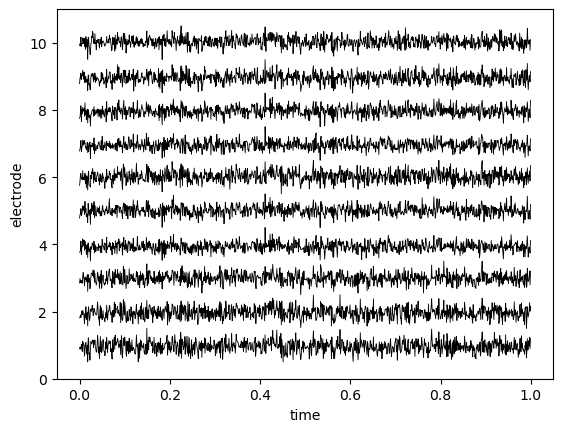

In [39]:
# simulate some data
bo_data = se.simulate_bo(n_samples=1000, sessions=2, n_elecs=10)

# plot it
bo_data.plot_data()

# get just data
data = bo_data.get_data()

We'll also simulate some electrode locations

In [23]:
locs = se.simulate_locations()
print(locs)

    x   y   z
0 -45  11 -28
1 -26   3 -17
2 -23  34  36
3 -13 -44  11
4  -7 -13  35
5   2 -18  42
6   5  -6  37
7  26 -40  40
8  36 -33  33
9  46  33  36


# Creating a brain object

To construct a new brain objects, simply pass the data and locations to the `Brain` class like this:

In [24]:
bo = se.Brain(data=data, locs=locs, sample_rate=100)

To view a summary of the contents of the brain object, you can call the `info` function:

In [25]:
bo.info()

Number of electrodes: 10
Recording time in seconds: [10.]
Sample Rate in Hz: [100]
Number of sessions: 1
Date created: Tue Jun  3 11:09:13 2025
Meta data: {}


Optionally, you can pass a `sessions` parameter, which is can be a numpy array or list the length of your data with a unique identifier for each session.  For example:

In [26]:
sessions = np.array([1]*(data.shape[0]/2)+[2]*(data.shape[0]/2))
bo = se.Brain(data=data, locs=locs, sample_rate=1000, sessions=sessions)
bo.info()

TypeError: can't multiply sequence by non-int of type 'float'

You can also add custom meta data to the brain object to help keep track of its contents. `meta` is a dictionary comprised of whatever you want:

In [ ]:
meta = {
    'subjectID' : '123',
    'Investigator' : 'Andy',
    'Hospital' : 'DHMC'
}
bo = se.Brain(data=data, locs=locs, sample_rate=1000, sessions=sessions, meta=meta)
bo.info()

NameError: name 'sessions' is not defined

# Initialize brain objects

`Brain` objects can be initialized by passing a any of the following to the `Brain` class instance initialization function:
- A path to a saved `Brain` object (ending in `.bo`)
- An existing `Brain` object (this creates a copy of the object)
- A path to or instance of any other supported toolbox type (`Model` objects or .mo files, or `Nifti` objects or .nii files)

In addition, `Brain` objects may be created via `load` by specifying `return_type='bo'`. 

For example: 

In [ ]:
nii_bo = se.Brain('example_nifti')

sizeof_hdr should be 348; set sizeof_hdr to 348
data code 26996 not recognized; not attempting fix
sizeof_hdr should be 348; set sizeof_hdr to 348
data code 26996 not recognized; not attempting fix


HeaderDataError: data code 26996 not recognized

Or:

In [ ]:
nii_bo = se.load('example_nifti', return_type='bo')

sizeof_hdr should be 348; set sizeof_hdr to 348
data code 26996 not recognized; not attempting fix
sizeof_hdr should be 348; set sizeof_hdr to 348
data code 26996 not recognized; not attempting fix


HeaderDataError: data code 26996 not recognized

Another feature, which can be particularly useful when working with large files, is loading only a subfield by specifiying `field`.  For example, if you only want to load locations:

In [ ]:
bo_locs = se.load('example_data', field='locs') 

# The structure of a brain object

Inside the brain object, the ECoG data are stored in a Pandas DataFrame that can be accessed with the `get_data` function:

In [ ]:
bo.get_data().head()

,0,1,2,3,4,5,6,7,8,9
0,-0.943555,-0.435915,0.009169,0.037509,0.337686,-0.577551,0.254801,-0.397001,-0.740196,0.229694
1,-0.475144,-0.037838,-0.987249,0.189752,-0.075171,0.328924,0.176517,0.475704,-0.496274,-0.211550
2,-0.811731,0.331674,-0.425510,-2.475280,-2.076882,-1.046699,-1.786317,-1.736743,-1.683735,-1.293592
3,-0.301416,-0.465283,-0.478934,-0.197540,-0.276842,-0.760325,-0.053963,-0.867371,-0.422767,-0.696130
4,-0.076979,0.455827,0.112481,0.244999,1.133559,0.462474,-0.358020,0.974962,0.360943,-0.024408


Similarly, the electrode locations are stored as a Pandas DataFrame, and can be retrieved using the `get_locs` method:

In [ ]:
bo.get_locs().head()

,x,y,z
0,-44,-25,2
1,-37,-3,15
2,-33,-8,23
3,-29,-13,4
4,-27,-6,10


Brain objects are iterable, so you index a brain object like this:

In [ ]:
#return first time sample
bo[0]
#return first 3 time samples
bo[:3] 
#return first electrode
bo[:, 0] 
#returns first 3 timesamples/elecs
bo_i = bo[:3, :3] 
bo_i.get_data()

,0,1,2
0,-0.943555,-0.435915,0.009169
1,-0.475144,-0.037838,-0.987249
2,-0.811731,0.331674,-0.425510


You can also pass a list of indices for either `times` (sample numbers) or `locs` to the `get_slice` method and return a subset of the brain object.

In [ ]:
bo_s = bo.get_slice(sample_inds=[0,1,2], loc_inds=[0,1,2])
bo_s.get_data()

,0,1,2
0,-0.943555,-0.435915,0.009169
1,-0.475144,-0.037838,-0.987249
2,-0.811731,0.331674,-0.425510


You can resample your data by specifying a new sample rate

In [ ]:
bo.resample(64)
bo.info()

Number of electrodes: 10
Recording time in seconds: [10.]
Sample Rate in Hz: [64]
Number of sessions: 1
Date created: Tue Jun  3 11:07:59 2025
Meta data: {}


You can also plot both the data and the electrode locations:

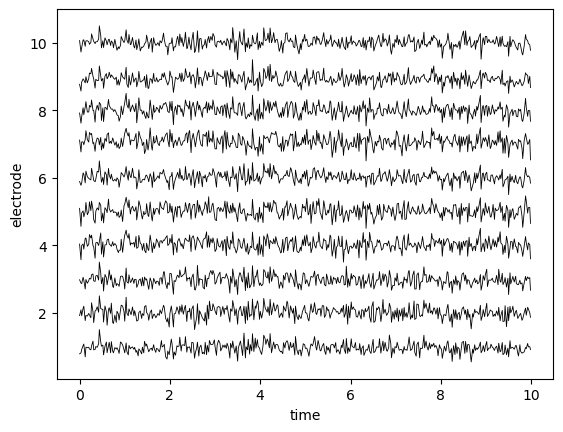

In [ ]:
bo.plot_data()

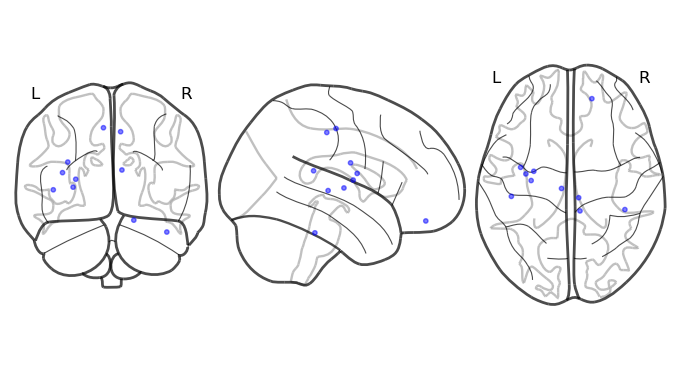

In [ ]:
bo.plot_locs()

The other pieces of the brain object are listed below:

In [ ]:
# array of session identifiers for each timepoint
sessions = bo.sessions

# number of sessions
n_sessions = bo.n_sessions

# sample rate
sample_rate = bo.sample_rate

# number of electrodes
n_elecs = bo.n_elecs

# length of each recording session in seconds
n_seconds = bo.dur

# the date and time that the bo was created
date_created = bo.date_created

# kurtosis of each electrode
kurtosis = bo.kurtosis

# meta data
meta = bo.meta

# label delinieating observed and reconstructed locations
label = bo.label

# Brain object methods

There are a few other useful methods on a brain object

## `bo.info()`

This method will give you a summary of the brain object:

In [27]:
bo.info()

Number of electrodes: 10
Recording time in seconds: [10.]
Sample Rate in Hz: [100]
Number of sessions: 1
Date created: Tue Jun  3 11:09:13 2025
Meta data: {}


## `bo.apply_filter()`
This method will return a filtered copy of the brain object. 

In [28]:
bo_f = bo.apply_filter()

## `bo.get_data()`

In [29]:
data_array = bo.get_data()

## `bo.get_zscore_data()`

This method will return a numpy array of the zscored data:

In [30]:
zdata_array = bo.get_zscore_data()

## `bo.get_locs()`

This method will return a numpy array of the electrode locations:

In [31]:
locs = bo.get_locs()

## `bo.get_slice()`
This method allows you to slice out time and locations from the brain object, and returns a brain object. This can occur in place if you set the flag `inplace=True`.

In [32]:
bo_slice = bo.get_slice(sample_inds=None, loc_inds=None, inplace=False)

## `bo.resample()`
This method allows you resample a brain object in place. 

In [33]:
bo.resample(resample_rate=None)

## `bo.plot_data()`

This method normalizes and plots data from brain object:

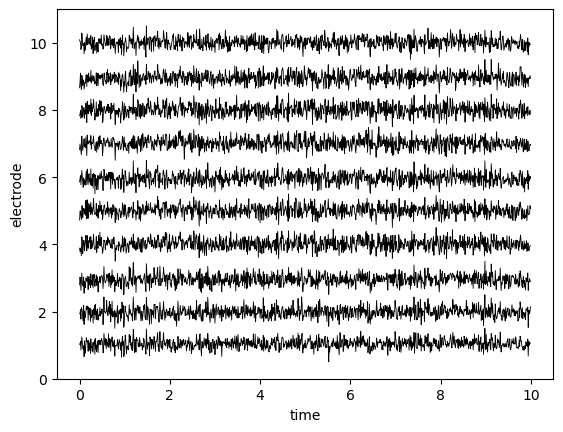

In [34]:
bo.plot_data()

## `bo.plot_locs()`
This method plots electrode locations from brain object:

In [35]:
bo_f = se.load('example_filter')

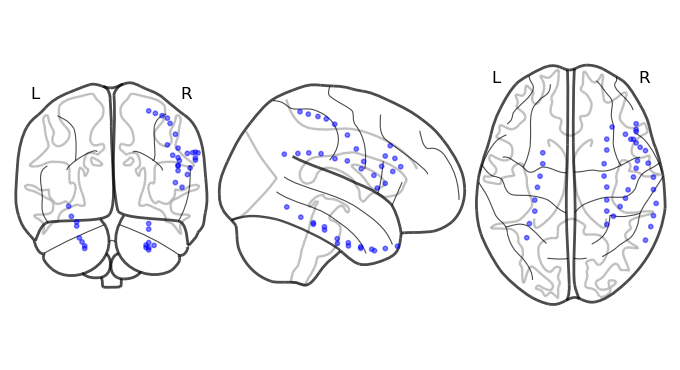

In [36]:
bo_f.plot_locs()

## `bo.to_nii()`

This method converts the brain object into supereeg's `nifti` class (a subclass of the `nibabel` nifti class).  If `filepath` is specified, the nifti file will be saved. You can also specify a nifti template with the `template` argument. If no template is specified, it will use the gray matter masked MNI 152 brain downsampled to 6mm.  

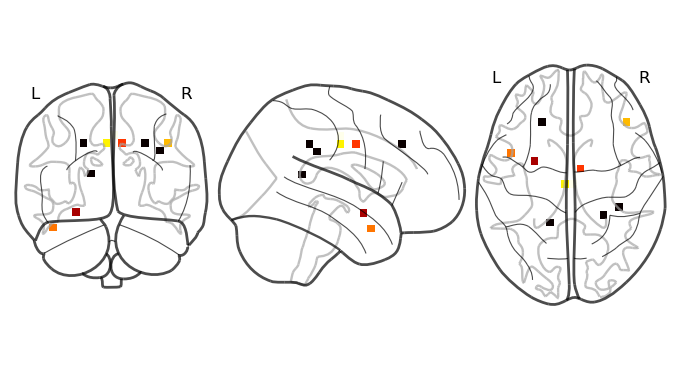

In [37]:
# convert to nifti
nii = bo.to_nii(template='gray', vox_size=6)

# plot first timepoint
nii.plot_glass_brain()

# save the file
# nii = bo.to_nii(filepath='/path/to/file/brain')

# specify a template and resolution
# nii = bo.to_nii(template='/path/to/nifti/file.nii', vox_size=20)

## `bo.save(fname='something')`

This method will save the brain object to the specified file location.
The data will be saved as a 'bo' file, which is a dictionary containing the elements of a brain object saved in the hd5 format using `deepdish`.

In [ ]:
#bo.save(fname='brain_object')